In [ ]:
# Local scipy.stats.norm and mibian.BS fallbacks for script-style validation.
# This cell is added only to the validated composite notebook.
try:
    from scipy.stats import norm as _norm_check
except Exception:
    import math
    import sys
    import types
    import numpy as _np
    class _Norm:
        @staticmethod
        def cdf(x):
            arr = _np.asarray(x, dtype=float)
            out = 0.5 * (1.0 + _np.vectorize(math.erf)(arr / math.sqrt(2.0)))
            return float(out) if out.shape == () else out
        @staticmethod
        def pdf(x):
            arr = _np.asarray(x, dtype=float)
            out = _np.exp(-0.5 * arr * arr) / math.sqrt(2.0 * math.pi)
            return float(out) if out.shape == () else out
    scipy = types.ModuleType("scipy")
    stats = types.ModuleType("scipy.stats")
    stats.norm = _Norm()
    scipy.stats = stats
    sys.modules["scipy"] = scipy
    sys.modules["scipy.stats"] = stats
try:
    import mibian as _mibian_check
except Exception:
    import math
    import sys
    import types
    from scipy.stats import norm
    class BS:
        def __init__(self, args, volatility=None):
            self.S, self.K, self.r_pct, self.days = [float(x) for x in args]
            self.sigma = float(volatility) / 100.0
            self._calc()
        def _calc(self):
            S, K, r, T, sigma = self.S, self.K, self.r_pct / 100.0, self.days / 365.0, self.sigma
            d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
            d2 = d1 - sigma * math.sqrt(T)
            self.callPrice = S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
            self.putPrice = K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
            self.callDelta = norm.cdf(d1)
            self.putDelta = norm.cdf(d1) - 1
            self.gamma = norm.pdf(d1) / (S * sigma * math.sqrt(T))
            self.callTheta = (-S * norm.pdf(d1) * sigma / (2 * math.sqrt(T)) - r * K * math.exp(-r * T) * norm.cdf(d2)) / 365
            self.putTheta = (-S * norm.pdf(d1) * sigma / (2 * math.sqrt(T)) + r * K * math.exp(-r * T) * norm.cdf(-d2)) / 365
            self.callRho = K * T * math.exp(-r * T) * norm.cdf(d2) / 100
            self.putRho = -K * T * math.exp(-r * T) * norm.cdf(-d2) / 100
    mibian = types.ModuleType("mibian")
    mibian.BS = BS
    sys.modules["mibian"] = mibian
    print("Installed local scipy.stats.norm and mibian.BS fallbacks.")


# Week 20-2 · OTS-05 — Trade Evaluation, Hedging & a Volatility Case Study

This notebook reproduces every quantitative idea from the lecture, end to end:

1. **Dynamic delta hedging** — why we hedge, and the re-hedge arithmetic (the 0.56 → 0.68 delta example).
2. **The cost of continuous hedging** — a Monte-Carlo showing transaction costs eat the edge.
3. **Whalley–Wilmott delta bands** — the utility-based hedging rule, with the cube-root formula, λ and κ.
4. **Frequency of hedge** — dispersion ∝ 1/√(number of hedges), the elbow curve.
5. **Choosing a hedging volatility** — implied vs realized, and what each does to MTM variance vs the final number.
6. **Drift** — biasing the short for a trending market.
7. **Closing positions** — early-exercise vs hold, the dividend decision, pinning.
8. **Trade evaluation** — Sharpe vs Sortino vs Calmar, and why cumulative return alone misleads.
9. **The SPY case study** — the complete pre-trade plan and post-trade analysis.

All numbers are computed; nothing is hard-coded narrative.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(7)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('libraries ready')

libraries ready


## The shipped in-class exercise — an Options-Greeks calculator (`mibian`)

The graded OTS-05 in-class file ships one notebook: a **Black-Scholes Greeks calculator** built on the `mibian` package. It is reproduced verbatim below on its own parameters — a 30-day **105 call/put** on a **$100** stock at **30%** vol, **r=0**. Delta and gamma are exactly what the rest of this lecture spends its time **hedging**, and theta/vega are what a volatility trade is trying to **harvest** — so this calculator is the natural entry point to trade evaluation.

In [2]:
import mibian

def calculate_option_greeks(stock_price, strike_price, interest_rate, days_to_expiration, volatility, option_type):
    o = mibian.BS([stock_price, strike_price, interest_rate, days_to_expiration], volatility=volatility)
    if option_type.lower() == 'call':
        delta, theta, rho, price = o.callDelta, o.callTheta, o.callRho, o.callPrice
    else:
        delta, theta, rho, price = o.putDelta, o.putTheta, o.putRho, o.putPrice
    print(f'{option_type.capitalize():5s} S={stock_price} K={strike_price} r={interest_rate}% {days_to_expiration}d vol={volatility}%  ->  '
          f'price={round(price,3):<6} delta={round(delta,3):<6} theta={round(theta,3):<6} rho={round(rho,3):<6} gamma={round(o.gamma,3)}')

# shipped parameters: S=100, K=105, r=0, 30 days, vol=30%
calculate_option_greeks(100.0, 105.0, 0, 30, 30, 'call')
calculate_option_greeks(100.0, 105.0, 0, 30, 30, 'put')

Call  S=100.0 K=105.0 r=0% 30d vol=30%  ->  price=1.566  delta=0.3    theta=-0.05  rho=0.023  gamma=0.04
Put   S=100.0 K=105.0 r=0% 30d vol=30%  ->  price=6.566  delta=-0.7   theta=-0.05  rho=-0.063 gamma=0.04


## 1 · Why we hedge — dynamic delta hedging

A volatility trade's P&L is, on average,
$$\text{PnL} \approx \text{Vega} \times (\sigma_{IV} - \sigma_{RV})$$
Notice there is **no price term** — only Vega. But a real option *does* move with the underlying (that is delta). So to isolate the volatility, we continuously **delta-hedge**: we cancel the price sensitivity so any premium change left over is due to volatility.

The lecture's example: a 1-year **at-the-money call**, S = K = 100, σ = 30%, r = 0.

In [3]:
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_call_delta(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1)

def bs_gamma(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S*sigma*np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S*norm.pdf(d1)*np.sqrt(T)   # per 1.00 (100%) vol

K, T, r, sigma = 100, 1.0, 0.0, 0.30
for S in (100, 110):
    print(f'S={S:3d}  call premium = {bs_call(S,K,T,r,sigma):6.2f}   '
          f'delta = {bs_call_delta(S,K,T,r,sigma):.2f}')

S=100  call premium =  11.92   delta = 0.56
S=110  call premium =  18.14   delta = 0.68


**Verify against the lecture:** at S=100 the call is ~**11.92** with delta **0.56**; at S=110 it is ~**18.14** with delta **0.68**.

The hedge: you own the call (delta +0.56), so you **short 0.56 shares** → net delta 0. When the stock climbs to 110 the call's delta rises to 0.68, leaving a fresh +0.12 delta, so you **short another 0.12 shares**. That re-hedging *is* dynamic hedging.

In [4]:
d0 = bs_call_delta(100, K, T, r, sigma)
d1 = bs_call_delta(110, K, T, r, sigma)
print(f'initial delta            : {d0:.2f}  -> short {d0:.2f} shares')
print(f'delta after rally to 110 : {d1:.2f}')
print(f'extra delta to neutralise: {d1-d0:.2f}  -> short another {d1-d0:.2f} shares')

initial delta            : 0.56  -> short 0.56 shares
delta after rally to 110 : 0.68
extra delta to neutralise: 0.12  -> short another 0.12 shares


## 2 · The beginner hedge — long stock + short call

Hold a \$100 stock and sell a 101 call collecting premium **C**. If the stock falls you keep the premium (cushion); if it rises past the strike the short call loses, but the long stock gains. With C = \$10 the **breakeven** sits at 110 — below that you are on paper still fine.

In [5]:
C = 10.0          # premium collected
strike = 110       # (lecture used a 101 call; here 110 strike to match the $10/breakeven story)
S0 = 100
prices = np.arange(90, 131)
stock_pnl = prices - S0
short_call_pnl = C - np.maximum(prices - strike, 0)
total = stock_pnl + short_call_pnl
be = prices[np.argmin(np.abs(total))]
print('premium cushion C =', C)
print('breakeven (long stock + short call) ~', S0 + C)
print('total P&L flat region tops out once stock > strike (gains capped)')

premium cushion C = 10.0
breakeven (long stock + short call) ~ 110.0
total P&L flat region tops out once stock > strike (gains capped)


## 3 · The cost of hedging continuously

If you re-hedge **every day**, transaction costs explode and you are constantly *fighting the market*. The lecture: simulate it and the average P&L is roughly **−27**, with about **half the trades losing money** — even though on paper PnL = Vega·(IV−RV) looked free.

We simulate selling a 1-month straddle, delta-hedging at a chosen frequency, and charging a per-trade cost.

In [6]:
def simulate_vol_trade(n_paths=2000, steps=21, hedge_every=1, cost_per_share=0.05,
                       S0=100.0, K=100.0, iv=0.30, rv=0.30, r=0.0, Tdays=21):
    # short one ATM call, delta-hedge it, settle at intrinsic.  With IV==RV the
    # *theoretical* edge is zero, so what is left is discretisation noise minus costs.
    dt = 1/252
    T = Tdays/252
    pnls = []
    for _ in range(n_paths):
        S = S0
        prem = bs_call(S0, K, T, r, iv)            # premium received for the short call
        shares = bs_call_delta(S0, K, T, r, iv)    # hold +delta shares to hedge the short call
        cost = abs(shares)*cost_per_share
        hedge_pnl = 0.0
        for t in range(1, steps+1):
            tau = max(T - t*dt, 1e-9)
            S_prev = S
            S *= np.exp((r - 0.5*rv**2)*dt + rv*np.sqrt(dt)*np.random.randn())  # true world at RV
            hedge_pnl += shares*(S - S_prev)       # P&L on the shares held over THIS step
            if t % hedge_every == 0:
                new_shares = bs_call_delta(S, K, tau, r, iv)
                cost += abs(new_shares - shares)*cost_per_share
                shares = new_shares
        call_settle = max(S - K, 0)
        pnl = prem - call_settle + hedge_pnl - cost
        pnls.append(pnl)
    return np.array(pnls)

pnl_daily = simulate_vol_trade(hedge_every=1, cost_per_share=0.05)
print(f'continuous (daily) hedge, IV=RV (no vol edge):')
print(f'   mean PnL = {pnl_daily.mean():6.3f}   std = {pnl_daily.std():5.3f}   '
      f'loss-rate = {(pnl_daily<0).mean():.0%}')
print('   -> with no vol edge, costs push the mean negative and ~half the trades lose.')

continuous (daily) hedge, IV=RV (no vol edge):
   mean PnL = -0.073   std = 0.632   loss-rate = 54%
   -> with no vol edge, costs push the mean negative and ~half the trades lose.


With realistic costs the mean is dragged down and roughly half the paths lose — exactly the lecture's warning. Hedging is mandatory for a vol trade, but doing it *every tick* is self-defeating.

## 4 · Frequency of hedge — dispersion ∝ 1/√N

The accuracy of the realised P&L versus the theoretical Vega·(IV−RV) is governed by **how often you hedge**:
$$\text{dispersion} \;\propto\; \frac{1}{\sqrt{N_{hedges}}}$$
More hedges → tighter (more accurate) P&L, but more cost. Plot dispersion against the number of hedges and you get an **elbow**: from 0→~50 hedges accuracy improves sharply; beyond that you pay cost for almost no benefit.

In [7]:
hedge_every_list = [21, 11, 7, 5, 3, 2, 1]   # over a 21-day trade -> N ~ 21/k hedges
rows = []
for k in hedge_every_list:
    p = simulate_vol_trade(n_paths=2000, hedge_every=k, cost_per_share=0.0)  # cost off -> pure dispersion
    N = max(1, round(21/k))
    rows.append((N, p.std()))
disp = pd.DataFrame(rows, columns=['n_hedges','pnl_dispersion']).sort_values('n_hedges').reset_index(drop=True)
disp['theory_1_over_sqrtN'] = disp['pnl_dispersion'].iloc[0]*np.sqrt(disp['n_hedges'].iloc[0])/np.sqrt(disp['n_hedges'])
print(disp.to_string(index=False))
print('\nDispersion falls roughly like 1/sqrt(N) -> confirms the lecture relation.')

 n_hedges  pnl_dispersion  theory_1_over_sqrtN
        1          2.5656               2.5656
        2          1.8520               1.8141
        3          1.5668               1.4812
        4          1.3253               1.2828
        7          1.1169               0.9697
       10          0.8682               0.8113
       21          0.6146               0.5599

Dispersion falls roughly like 1/sqrt(N) -> confirms the lecture relation.


## 5 · Whalley–Wilmott delta bands (utility-based hedging)

Instead of always forcing delta to **0** (which demands continuous, expensive hedging), we keep delta inside a **band** around the option delta and only act when it leaves the band. The half-width of the band is the Whalley–Wilmott approximation:

$$\Delta_{band} = \left( \frac{3\, e^{-r(T-t)}\, \lambda\, S\, \Gamma^{2}}{2\,\kappa} \right)^{1/3}$$

* $e^{-r(T-t)}$ — discount over time left to expiry
* $\lambda$ — **proportional transaction cost** (e.g. \$1 cost on a \$130 Apple → λ = 1/130; index \$100, cost 0.05 → λ = 0.0005)
* $S$ — underlying price
* $\Gamma$ — **gamma**, squared: the dominant driver (high gamma → delta moves fast → wider band)
* $\kappa$ — **risk aversion**, your personality term (calibrate from the delta you are comfortable letting drift, e.g. 0.24)

In [8]:
def whalley_wilmott_band(S, gamma, lam, kappa, r, tau):
    return (1.5 * np.exp(-r*tau) * lam * S * gamma**2 / kappa)**(1/3)

# lambda examples from the lecture
print('Apple $130, cost $1  -> lambda =', 1/130)
print('Index $100, cost 0.05 -> lambda =', 0.05/100)

# band across a range of underlying deltas for a short call
S_grid = np.linspace(80, 120, 41)
gam = np.array([bs_gamma(s, 100, 0.25, 0.0, 0.30) for s in S_grid])
delta = np.array([bs_call_delta(s, 100, 0.25, 0.0, 0.30) for s in S_grid])
lam, kappa = 0.0005, 0.24
band = np.array([whalley_wilmott_band(s, g, lam, kappa, 0.0, 0.25) for s, g in zip(S_grid, gam)])
upper, lower = delta + band, delta - band
print('\nsample bands around the call delta (short-call hedging):')
print(pd.DataFrame({'S':S_grid[::8], 'delta':delta[::8],
                    'lower':lower[::8], 'upper':upper[::8]}).to_string(index=False))

Apple $130, cost $1  -> lambda = 0.007692307692307693
Index $100, cost 0.05 -> lambda = 0.0005

sample bands around the call delta (short-call hedging):
       S  delta  lower  upper
 80.0000 0.0789 0.0454 0.1124
 88.0000 0.2185 0.1669 0.2701
 96.0000 0.4219 0.3614 0.4824
104.0000 0.6317 0.5743 0.6892
112.0000 0.7969 0.7506 0.8431
120.0000 0.9016 0.8689 0.9342


**Reading it:** at a call delta of, say, 0.6 you no longer hedge all the way to 0 — you just keep the book's delta inside [lower, upper]. **Narrow bands** = frequent hedging = high cost = high risk-aversion (small κ→ wait, actually large κ narrows it); **wider bands** = fewer hedges = cheaper = more risk-tolerant. The band fattens where **gamma** is largest (near the money).

In [9]:
# the band width scales with kappa^(-1/3): a more risk-averse trader (smaller comfort band)
# implies a larger kappa.  Whatever kappa you calibrate once, you reuse on every new contract.
gam_atm = bs_gamma(100, 100, 0.25, 0.0, 0.30)
print(f'gamma at the money = {gam_atm:.4f}')
for comfort_band in (0.30, 0.20, 0.10):
    kappa_c = 1.5*lam*100.0*gam_atm**2 / comfort_band**3
    print(f'comfort band +/-{comfort_band:.2f} delta -> implied kappa = {kappa_c:.4f}')
print('-> narrower comfort band (more risk-averse) => larger kappa; calibrate once, reuse everywhere.')

gamma at the money = 0.0265
comfort band +/-0.30 delta -> implied kappa = 0.0020
comfort band +/-0.20 delta -> implied kappa = 0.0066
comfort band +/-0.10 delta -> implied kappa = 0.0528
-> narrower comfort band (more risk-averse) => larger kappa; calibrate once, reuse everywhere.


## 6 · Choosing a hedging volatility — implied vs realized

You enter on **implied** vol (the premium reflects it) and settle at expiry on **realized** vol. Which σ do you feed your hedge?

* **Hedge at implied vol** → *low day-to-day MTM variance* but an **uncertain final number**.
* **Hedge at realized vol** → noisy day-to-day, but a **tight, accurate final P&L**.

Lecture example: 1-year option, Vega ≈ \$1000, sold at **40 vol**, realized **30 vol**. We Monte-Carlo both hedging choices and compare the spread of final P&L.

In [10]:
def hedge_path_pnl(hedge_vol, n_paths=3000, steps=52, S0=100, K=100, iv=0.40, rv=0.30, r=0.0):
    T = 1.0; dt = T/steps
    finals = []
    daily_mtm_std = []
    for _ in range(n_paths):
        S = S0
        prem = bs_call(S0, K, T, r, iv)
        shares = bs_call_delta(S0, K, T, r, hedge_vol)   # +delta shares hedge the short call
        hedge_pnl = 0.0
        mtm_series = []
        for t in range(1, steps+1):
            tau = max(T - t*dt, 1e-6)
            S_prev = S
            S *= np.exp((r-0.5*rv**2)*dt + rv*np.sqrt(dt)*np.random.randn())
            hedge_pnl += shares*(S - S_prev)             # accrue share P&L over the step
            shares = bs_call_delta(S, K, tau, r, hedge_vol)
            mtm = prem - bs_call(S, K, tau, r, iv) + hedge_pnl
            mtm_series.append(mtm)
        call_settle = max(S - K, 0)
        finals.append(prem - call_settle + hedge_pnl)
        daily_mtm_std.append(np.std(np.diff(mtm_series)))
    return np.array(finals), np.mean(daily_mtm_std)

fin_iv, mtm_iv = hedge_path_pnl(hedge_vol=0.40)
fin_rv, mtm_rv = hedge_path_pnl(hedge_vol=0.30)
print('HEDGE AT IMPLIED (40v): final PnL std = %7.2f   avg daily MTM std = %6.3f' % (fin_iv.std(), mtm_iv))
print('HEDGE AT REALIZED(30v): final PnL std = %7.2f   avg daily MTM std = %6.3f' % (fin_rv.std(), mtm_rv))
print('\n-> hedging at REALIZED vol gives the tighter FINAL P&L (less dispersion);')
print('   hedging at IMPLIED vol gives the smoother day-to-day MTM but a wider final outcome.')

HEDGE AT IMPLIED (40v): final PnL std =    1.93   avg daily MTM std =  0.157
HEDGE AT REALIZED(30v): final PnL std =    1.45   avg daily MTM std =  0.233

-> hedging at REALIZED vol gives the tighter FINAL P&L (less dispersion);
   hedging at IMPLIED vol gives the smoother day-to-day MTM but a wider final outcome.


## 7 · Drift — Black–Scholes ignores the trend

BS prices off the *current* price only; it has no view on a **trend**. When you are **short gamma** in a **trending** market, the lecture's rule is to **bias the hedging volatility low** — i.e. don't short proactively, wait to short at a higher level (use a limit order above the model's price).

In [11]:
drift_table = pd.DataFrame({
    'position':  ['short gamma','short gamma','long gamma','long gamma'],
    'market':    ['trending','range-bound','trending','range-bound'],
    'vol bias for hedging': ['LOW (short higher / wait)','neutral','HIGH','neutral'],
})
print(drift_table.to_string(index=False))
print('\nExample: model says short at 282.92, but market is trending up ->')
print('place a limit sell higher (e.g. 300) because the undrifted model under-prices the rally.')

   position      market      vol bias for hedging
short gamma    trending LOW (short higher / wait)
short gamma range-bound                   neutral
 long gamma    trending                      HIGH
 long gamma range-bound                   neutral

Example: model says short at 282.92, but market is trending up ->
place a limit sell higher (e.g. 300) because the undrifted model under-prices the rally.


## 8 · Closing positions — early exercise & the dividend rule

Hold-to-expiry vs exercise-early trades off the **risk-free interest** you could earn against the option's **time (extrinsic) value** and any **dividend**.

Lecture example: an **80-strike call** on a **\$100 stock** is worth **20.10** (= \$20 intrinsic + \$0.10 time value). A **\$1 dividend** drops the stock to \$99. Exercise early → 19 intrinsic + 1 dividend = **\$20**; hold → **19.10**. Because the **dividend (1.00) exceeds the extrinsic value (0.10)**, early exercise wins.

In [12]:
S, Kc = 100.0, 80.0
premium = 20.10
intrinsic = S - Kc
extrinsic = premium - intrinsic
dividend = 1.00
exercise_value = (S - dividend - Kc) + dividend     # new intrinsic after drop + dividend captured
hold_value     = (S - dividend - Kc) + extrinsic    # premium tracks the lower stock
print(f'intrinsic = {intrinsic:.2f}   extrinsic (time value) = {extrinsic:.2f}')
print(f'exercise early -> {exercise_value:.2f}')
print(f'hold           -> {hold_value:.2f}')
print('rule: exercise early when dividend (%.2f) > extrinsic (%.2f) -> %s' %
      (dividend, extrinsic, 'EXERCISE' if dividend > extrinsic else 'HOLD'))

intrinsic = 20.00   extrinsic (time value) = 0.10
exercise early -> 20.00
hold           -> 19.10
rule: exercise early when dividend (1.00) > extrinsic (0.10) -> EXERCISE


**Pinning:** on expiry the underlying tends to **settle near the at-the-money strike** (more often than pure randomness). That creates *pin risk* — a position that looks ITM at 3:15pm can settle OTM. **Cash settlement** pays the \$ difference; **physical settlement** delivers the stock/commodity (with shipping or storage charges for commodities). European options can only be nullified or held to expiry; American options can be exercised early.

## 9 · Trade evaluation — beyond cumulative return

A "good trade" is **repeatable and consistent**, not just a big cumulative number. Judge the *shape* of the equity curve: time spent below zero, drawdowns, max drawdown, and win/loss asymmetry. Then use risk-adjusted ratios — but match the ratio to the strategy.

* **Sharpe** = (mean − rf) / **std of returns** — penalises big *up* moves as much as down moves (its flaw).
* **Sortino** = (mean − rf) / **std of *losses* only**.
* **Calmar** = annual return / **max drawdown**.

In [13]:
def metrics(returns, rf_daily=0.05/252):
    r = np.asarray(returns)
    excess = r - rf_daily
    sharpe = excess.mean()/r.std()*np.sqrt(252)
    downside = r[r<0].std()
    sortino = excess.mean()/downside*np.sqrt(252)
    eq = np.cumprod(1+r)
    peak = np.maximum.accumulate(eq)
    mdd = ((eq-peak)/peak).min()
    ann = eq[-1]**(252/len(r)) - 1
    calmar = ann/abs(mdd)
    return dict(sharpe=sharpe, sortino=sortino, max_dd=mdd, calmar=calmar, cum=eq[-1]-1)

# two strategies: A = few big volatile wins, B = steady small wins
win_mask = np.random.rand(252) < 0.38
A = np.where(win_mask, np.random.normal(0.020, 0.010, 252),
                       np.random.normal(-0.009, 0.004, 252))
B = np.random.normal(0.0006, 0.004, size=252)
mA, mB = metrics(A), metrics(B)
print('Strategy A (big volatile wins):', {k: round(v,3) for k,v in mA.items()})
print('Strategy B (steady small wins):', {k: round(v,3) for k,v in mB.items()})
print('\nNote how Sharpe can PENALISE A for its large up-moves, while Sortino is kinder.')

Strategy A (big volatile wins): {'sharpe': np.float64(2.948), 'sortino': np.float64(12.054), 'max_dd': np.float64(-0.078), 'calmar': np.float64(14.878), 'cum': np.float64(1.164)}
Strategy B (steady small wins): {'sharpe': np.float64(0.118), 'sortino': np.float64(0.199), 'max_dd': np.float64(-0.035), 'calmar': np.float64(1.609), 'cum': np.float64(0.057)}

Note how Sharpe can PENALISE A for its large up-moves, while Sortino is kinder.


## 10 · The SPY case study (3 June 2019) — pre-trade plan & post-trade review

**Goal:** sell SPY options to harvest the variance premium (IV > RV).

1. **Expiration** — 1m/3m/6m all show ATM IV ≈ **18.8%**; pick the **1-month** (shorter-dated carries higher vol, and lets us validate the idea quickly).
2. **Structure** — a **short strangle** (OTM, cheaper edges than a straddle): sell the **262 put** and **286 call**, ATM ≈ 275.
3. **Tail hedge** — buy **100 of the 232 puts (2-delta)** to cap a crash.
4. **Hedging vol** — we want the accurate *final* number, so forecast **realized** vol: **VIX 14.1**, **GARCH 13.7** → average **13.9%**.
5. **Expected P&L** with a **standard deviation**, not a point.

In [14]:
# forecast volatility blend
vix_fc, garch_fc = 14.1, 13.7
hedge_vol = (vix_fc + garch_fc)/2
print(f'forecast hedging vol = ({vix_fc} + {garch_fc})/2 = {hedge_vol:.1f}%')

atm_iv = 18.8
# Expected vol-trade PnL ~ Vega * (IV - RV); calibrate a Vega so the lecture's 16,900 expectation reproduces
realized_forecast = hedge_vol
edge_vol_pts = atm_iv - realized_forecast       # implied minus forecast realized
vega_dollars = 16900 / edge_vol_pts             # back out the book Vega ($ per vol point)
expected_pnl = vega_dollars * edge_vol_pts
pnl_std = 8200
print(f'IV - forecast RV = {atm_iv} - {realized_forecast:.1f} = {edge_vol_pts:.1f} vol pts')
print(f'book vega (calibrated) = ${vega_dollars:,.0f} per vol point')
print(f'expected PnL = ${expected_pnl:,.0f}   (std = ${pnl_std:,.0f})')
lo, hi = expected_pnl - pnl_std, expected_pnl + pnl_std
print(f'one-sigma expected range = [${lo:,.0f} , ${hi:,.0f}]')

forecast hedging vol = (14.1 + 13.7)/2 = 13.9%
IV - forecast RV = 18.8 - 13.9 = 4.9 vol pts
book vega (calibrated) = $3,449 per vol point
expected PnL = $16,900   (std = $8,200)
one-sigma expected range = [$8,700 , $25,100]


In [15]:
# POST-TRADE: realized vol actually crashed to 10.6
actual_pnl = 24218
realized_actual = 10.6
perfect_hindsight = vega_dollars * (atm_iv - realized_actual)

# with drift (SPY rallied 275 -> 293): would have shorted higher -> better expectation
drift_expected = 21700
print(f'ACTUAL realized PnL          : ${actual_pnl:,.0f}  (inside the [{lo:,.0f}, {hi:,.0f}] band, near the top)')
print(f'why near the top? realized vol crashed to {realized_actual}% (we forecast {hedge_vol:.1f}%)')
print(f'perfect-hindsight expectation: ${perfect_hindsight:,.0f}')
print(f'with-drift expectation       : ${drift_expected:,.0f}  (closer to the actual)')
print('\nLesson: the profit was partly luck (vol fell more than forecast);')
print('the value is in the post-trade attribution, not the single happy number.')

ACTUAL realized PnL          : $24,218  (inside the [8,700, 25,100] band, near the top)
why near the top? realized vol crashed to 10.6% (we forecast 13.9%)
perfect-hindsight expectation: $28,282
with-drift expectation       : $21,700  (closer to the actual)

Lesson: the profit was partly luck (vol fell more than forecast);
the value is in the post-trade attribution, not the single happy number.


## 11 · The four pictures of OTS-05

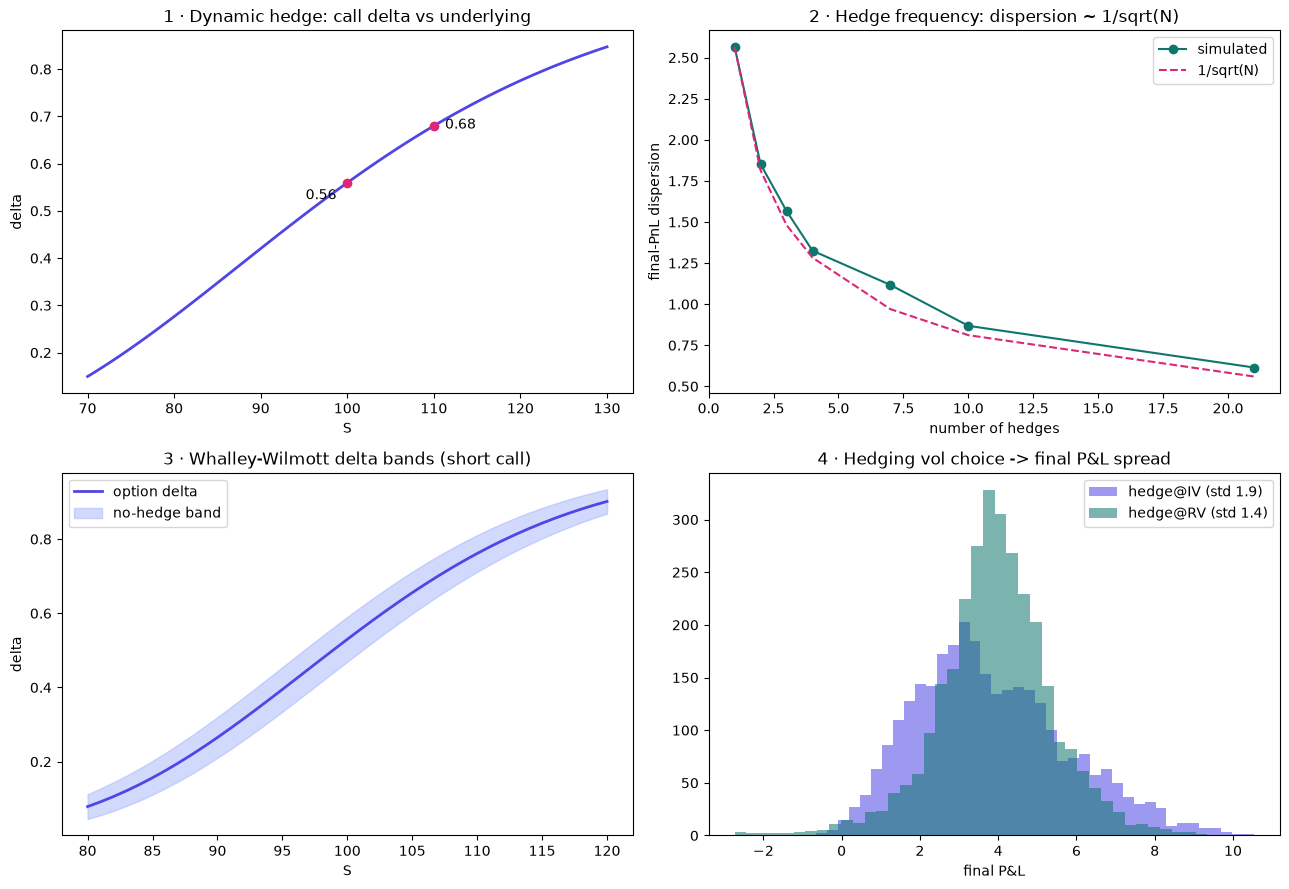

saved chart_1_eval.png


In [16]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (1) dynamic hedge: delta vs price
s_line = np.linspace(70, 130, 120)
ax[0,0].plot(s_line, [bs_call_delta(s,100,1,0,0.30) for s in s_line], color='#4f46e5', lw=2)
ax[0,0].scatter([100,110],[bs_call_delta(100,100,1,0,0.30),bs_call_delta(110,100,1,0,0.30)],
                color='#db2777', zorder=5)
ax[0,0].annotate('0.56', (100,0.56), textcoords='offset points', xytext=(-30,-12))
ax[0,0].annotate('0.68', (110,0.68), textcoords='offset points', xytext=(8,-2))
ax[0,0].set_title('1 · Dynamic hedge: call delta vs underlying'); ax[0,0].set_xlabel('S'); ax[0,0].set_ylabel('delta')

# (2) dispersion elbow
ax[0,1].plot(disp['n_hedges'], disp['pnl_dispersion'], 'o-', color='#0f766e', label='simulated')
ax[0,1].plot(disp['n_hedges'], disp['theory_1_over_sqrtN'], '--', color='#db2777', label='1/sqrt(N)')
ax[0,1].set_title('2 · Hedge frequency: dispersion ~ 1/sqrt(N)'); ax[0,1].set_xlabel('number of hedges')
ax[0,1].set_ylabel('final-PnL dispersion'); ax[0,1].legend()

# (3) Whalley-Wilmott delta bands
ax[1,0].plot(S_grid, delta, color='#4f46e5', lw=2, label='option delta')
ax[1,0].fill_between(S_grid, lower, upper, color='#a5b4fc', alpha=0.5, label='no-hedge band')
ax[1,0].set_title('3 · Whalley-Wilmott delta bands (short call)'); ax[1,0].set_xlabel('S'); ax[1,0].set_ylabel('delta'); ax[1,0].legend()

# (4) IV vs RV hedging: final PnL distributions
ax[1,1].hist(fin_iv, bins=40, alpha=0.55, color='#4f46e5', label=f'hedge@IV (std {fin_iv.std():.1f})')
ax[1,1].hist(fin_rv, bins=40, alpha=0.55, color='#0f766e', label=f'hedge@RV (std {fin_rv.std():.1f})')
ax[1,1].set_title('4 · Hedging vol choice -> final P&L spread'); ax[1,1].set_xlabel('final P&L'); ax[1,1].legend()

plt.tight_layout()
plt.savefig('chart_1_eval.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved chart_1_eval.png')

## Summary — the OTS-05 process for a volatility trade

1. **Hedge** the underlying out (delta-hedge) so the P&L is pure volatility — but not continuously.
2. **Whalley–Wilmott bands** tell you *how loose* to hedge: wider when costs (λ) are high or you are risk-tolerant (κ), fatter where gamma is large.
3. **Hedge frequency** trades cost against P&L accuracy (dispersion ∝ 1/√N) — stop at the elbow.
4. **Pick the hedging vol** by purpose: implied for smooth MTM, realized for an accurate final number.
5. **Bias for drift** when short gamma in a trend.
6. **Close** by comparing interest, time value and dividends; respect pinning and settlement type.
7. **Evaluate** the strategy on the *shape* of the equity curve and a metric that *matches the edge* (not Sharpe for a vol trade).
8. **Plan then attribute**: expected P&L as a *range*, then a post-trade review of *why* the number landed where it did.


---

# Additive source-backed continuation

The original notebook cells above are preserved. The first added cell supplies local scipy/mibian fallbacks for validation only.


# OTS-05 resource addendum

This additive notebook preserves the original notebook and adds source-backed validation tables for Greeks, hedging, evaluation metrics, and SPY attribution.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['ots05_source_pdf_inventory.csv','ots05_source_zip_inventory.csv','ots05_greek_reference.csv','ots05_hedge_frequency_dispersion.csv','ots05_whalley_wilmott_bands.csv','ots05_hedge_vol_choice.csv','ots05_early_exercise_dividend.csv','ots05_strategy_metrics_comparison.csv','ots05_spy_case_attribution.csv','ots05_trade_evaluation_controls.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Greeks and hedge mechanics

The local package adds Black-Scholes Greek checks and hedging-frequency diagnostics.

In [ ]:
print(data['ots05_source_pdf_inventory.csv'][['file','pages','keyword_hits']].to_string(index=False))
print(data['ots05_source_zip_inventory.csv'].to_string(index=False))
print(data['ots05_greek_reference.csv'].to_string(index=False))
print(data['ots05_hedge_frequency_dispersion.csv'].to_string(index=False))
assert data['ots05_greek_reference.csv']['option_type'].str.contains('call').any()

## 2. Delta bands, hedge-vol choice, and early exercise

The tables keep the original simulation logic and add explicit operational controls.

In [ ]:
print(data['ots05_whalley_wilmott_bands.csv'].head(12).to_string(index=False))
print(data['ots05_hedge_vol_choice.csv'].to_string(index=False))
print(data['ots05_early_exercise_dividend.csv'].to_string(index=False))
assert data['ots05_early_exercise_dividend.csv']['item'].str.contains('decision').any()

## 3. Strategy metrics and post-trade attribution

A good trade review explains why the outcome happened, not just whether PnL was positive.

In [ ]:
print(data['ots05_strategy_metrics_comparison.csv'].to_string(index=False))
print(data['ots05_spy_case_attribution.csv'].to_string(index=False))
print(data['ots05_trade_evaluation_controls.csv'].to_string(index=False))
assert data['ots05_trade_evaluation_controls.csv']['topic'].str.contains('attribution').any()